In [8]:
# IMPORTAR LIBRERÍAS

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)



TensorFlow version: 2.21.0


In [9]:
# PARÁMETROS DEL MODELO

IMG_SIZE = 128      # Tamaño estándar para EfficientNetB0
BATCH_SIZE = 32     # Cantidad de imágenes por paso
EPOCHS = 5          # Número de veces que verá el dataset completo

NUM_CLASSES = 10    # Tienes 10 clases

In [10]:
# PREPROCESAMIENTO DE IMÁGENES

base_dir  = "../data"
train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

# Generador de entrenamiento CON data augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,          # Voltear horizontalmente
    vertical_flip=True,            # Voltear verticalmente
    rotation_range=30,             # Rotar hasta 30 grados
    brightness_range=[0.8, 1.2],   # Variar brillo
    zoom_range=0.1                 # Zoom leve
)

# Generador para validación y test SIN augmentation, solo normalización, para evaluar con imágenes reales
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Dataset de entrenamiento
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Dataset de validación
val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Dataset de test
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 5946 images belonging to 10 classes.
Found 1273 images belonging to 10 classes.
Found 1273 images belonging to 10 classes.


In [11]:
# CARGAR EFFICIENTNET-B0

base_model = EfficientNetB0(
    weights='imagenet',                 # Usa pesos ya entrenados
    include_top=False,                  # Quitamos la capa final original
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False            # Congelamos la red base

In [12]:
# CREAR CAPA FINAL PERSONALIZADA

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

In [13]:
# COMPILAR MODELO

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,829 (16.08 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [14]:
# ENTRENAMIENTO

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Epoch 1/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 175s 888ms/step - accuracy: 0.6500 - loss: 1.0256 - val_accuracy: 0.8280 - val_loss: 0.5341
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 180s 968ms/step - accuracy: 0.8039 - loss: 0.5856 - val_accuracy: 0.8460 - val_loss: 0.4398
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.8340 - loss: 0.4918 - val_accuracy: 0.8712 - val_loss: 0.3758
Epoch 4/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 176s 945ms/step - accuracy: 0.8488 - loss: 0.4427 - val_accuracy: 0.8767 - val_loss: 0.3632
Epoch 5/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 214s 1s/step - accuracy: 0.8646 - loss: 0.3961 - val_accuracy: 0.8877 - val_loss: 0.3522


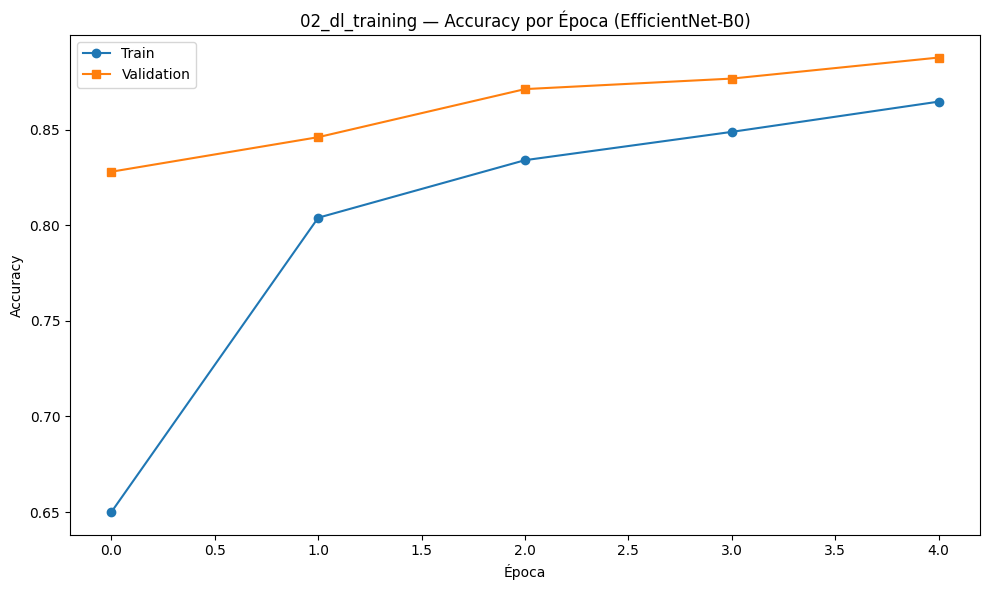

Gráfica guardada: ../outputs/graphics/02_dl_training_accuracy.png


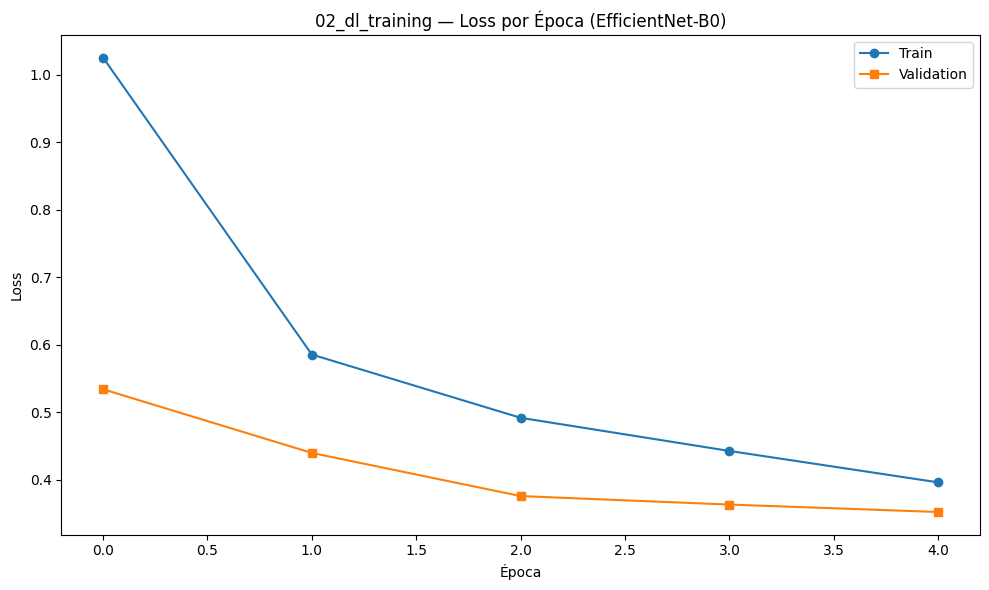

Gráfica guardada: ../outputs/graphics/02_dl_training_loss.png


In [15]:
# GRÁFICAS DE ENTRENAMIENTO

GRAPHICS_DIR = '../outputs/graphics'

# -- Accuracy --
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], marker='o', label='Train')
plt.plot(history.history['val_accuracy'], marker='s', label='Validation')
plt.title('02_dl_training — Accuracy por Época (EfficientNet-B0)')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig(f'{GRAPHICS_DIR}/02_dl_training_accuracy.png', dpi=150)
plt.show()
print(f'Gráfica guardada: {GRAPHICS_DIR}/02_dl_training_accuracy.png')

# -- Loss --
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], marker='o', label='Train')
plt.plot(history.history['val_loss'], marker='s', label='Validation')
plt.title('02_dl_training — Loss por Época (EfficientNet-B0)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig(f'{GRAPHICS_DIR}/02_dl_training_loss.png', dpi=150)
plt.show()
print(f'Gráfica guardada: {GRAPHICS_DIR}/02_dl_training_loss.png')


In [16]:
# MÉTRICAS

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
import seaborn as sns
import numpy as np

test_generator.reset()

predicciones = model.predict(
    test_generator,
    steps=test_generator.samples // BATCH_SIZE + 1
)

y_pred = np.argmax(predicciones, axis=1)
y_true = test_generator.classes

40/40 ━━━━━━━━━━━━━━━━━━━━ 34s 800ms/step


[[ 75   0   0   0   0   0   0   0   0   0]
 [  0 129   0   4   1   9   2   3   2   0]
 [  0   0 103   0   0   1   0   0   0   1]
 [  0   3   0 139   0   6   2   0   0   0]
 [  0   3   0   1 118   2   5  21   0   0]
 [  0   5   0  11   0 127   3   0   0   4]
 [  0   5   1   2   2  13 117   9   0   1]
 [  0   4   0   0   5   0   1 140   0   0]
 [  0   0   0   2   0   3   0   0  38   0]
 [  0   1   1   2   0   4   0   0   0 142]]


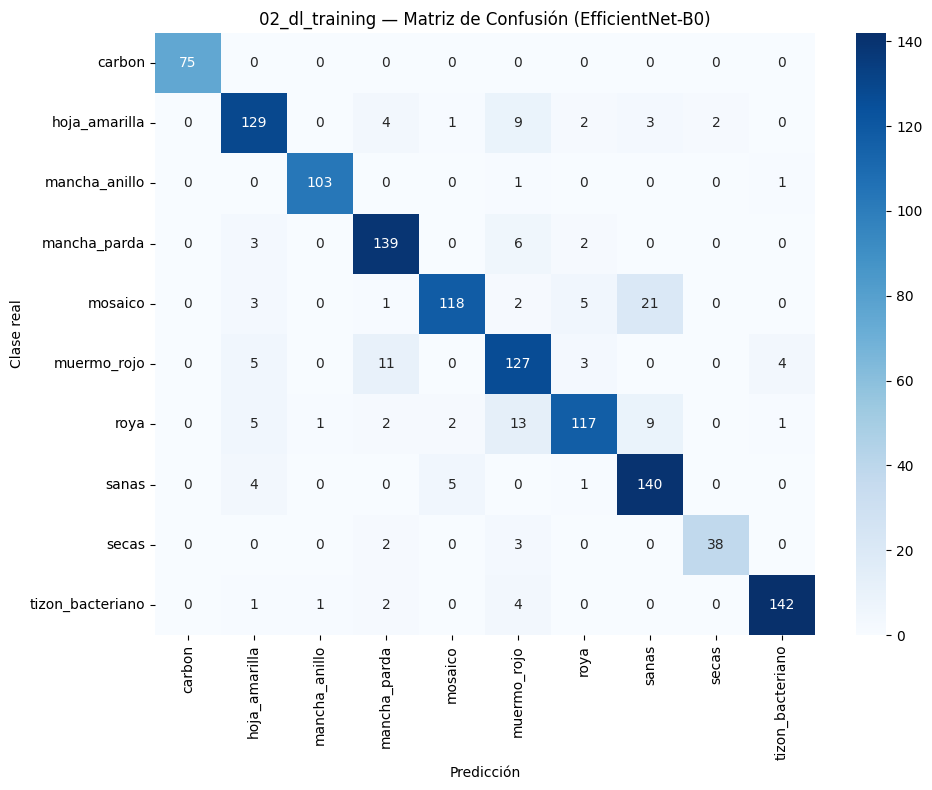

Gráfica guardada: ../outputs/graphics/02_dl_training_confusion_matrix.png


In [17]:
# MATRIZ DE CONFUSIÓN

cm = confusion_matrix(y_true, y_pred)
print(cm)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=test_generator.class_indices.keys(),
    yticklabels=test_generator.class_indices.keys()
)

plt.xlabel('Predicción')
plt.ylabel('Clase real')
plt.title('02_dl_training — Matriz de Confusión (EfficientNet-B0)')
plt.tight_layout()
plt.savefig(f'{GRAPHICS_DIR}/02_dl_training_confusion_matrix.png', dpi=150)
plt.show()
print(f'Gráfica guardada: {GRAPHICS_DIR}/02_dl_training_confusion_matrix.png')


In [18]:
# F1 SCORE

f1 = f1_score(y_true, y_pred, average='weighted')
print("F1 Score:", f1)

F1 Score: 0.8861048456585771


In [19]:
# REPORTE DE CLASIFICACIÓN

print(classification_report(
    y_true,
    y_pred,
    target_names=test_generator.class_indices.keys()
))

                  precision    recall  f1-score   support

          carbon       1.00      1.00      1.00        75
   hoja_amarilla       0.86      0.86      0.86       150
   mancha_anillo       0.98      0.98      0.98       105
    mancha_parda       0.86      0.93      0.89       150
         mosaico       0.94      0.79      0.86       150
     muermo_rojo       0.77      0.85      0.81       150
            roya       0.90      0.78      0.84       150
           sanas       0.81      0.93      0.87       150
           secas       0.95      0.88      0.92        43
tizon_bacteriano       0.96      0.95      0.95       150

        accuracy                           0.89      1273
       macro avg       0.90      0.89      0.90      1273
    weighted avg       0.89      0.89      0.89      1273



In [20]:
# GUARDAR EL MODELO

model.save('../models/dl_best_model.keras')